<a href="https://colab.research.google.com/github/DeepthiManthapuram/Feature_Selection_Methods/blob/main/Feature_Selection_Filter_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Variance threshold**

variance threshold removes the feature which has low variance.

In [1]:
import pandas as pd

data = pd.DataFrame({
    'age': [25, 30, 35, 40, 45],
    'salary': [5000, 6000, 7000, 8000, 9000],
    'country_code': [1, 1, 1, 1, 1]
})
data

,age,salary,country_code
0,25,5000,1
1,30,6000,1
2,35,7000,1
3,40,8000,1
4,45,9000,1


In [2]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold = 0.1)
selected_data = selector.fit_transform(data)

selected_features = data.columns[selector.get_support()]
print("Selected features: ",selected_features)

Selected features:  Index(['age', 'salary'], dtype='object')


Scenario: Hospital Disease Prediction System
You are building a machine learning model to predict whether a patient has a particular disease.
The dataset contains the following features:
Age
Blood Pressure
Cholesterol Level
Gender
Country Code
Hospital ID
Machine Version Used for Testing
After initial exploration, you notice:
Country Code is 100% “India” for all records
Machine Version is 99% “v2.1” and only 1% “v2.2”
Hospital ID is same for all patients
❓ Question:
Which feature selection technique would you apply first?
Which features would likely be removed?
Why is removing these features important before training?
What problem might occur if you keep them?


✅ 1️⃣ Which feature selection technique would you apply first?

👉 Variance Threshold (Low Variance Feature Removal)

This technique removes features that have almost no variation (same value for all or nearly all records).

Because here:

Country Code = 100% India

Hospital ID = Same for all

Machine Version = 99% same

These features have very low variance.

So first step = Remove low variance features.

✅ 2️⃣ Which features would likely be removed?

These features should be removed:

❌ Country Code
❌ Hospital ID
❌ Machine Version Used for Testing

Because:

They are constant or nearly constant

They do not help in distinguishing patients

✅ 3️⃣ Why is removing these features important before training?
🔹 Reason 1: They give NO useful information

If a feature has the same value for everyone, it cannot help the model differentiate between diseased and non-diseased patients.

Example:
If everyone is from India → Country Code cannot explain disease differences.

🔹 Reason 2: Reduces noise

Unnecessary features add confusion to the model.

🔹 Reason 3: Improves model performance

Faster training

Less memory usage

Better generalization

🔹 Reason 4: Prevents overfitting in some models

Some models may try to find patterns in useless features.

✅ 4️⃣ What problem might occur if you keep them?

If you keep them:

⚠️ Problem 1: Model learns nothing from them

They add no predictive power.

⚠️ Problem 2: Increased computation time

More features = more calculations.

⚠️ Problem 3: Risk of bias (in other scenarios)

If hospital ID differed across hospitals, the model might learn hospital pattern instead of disease pattern.

⚠️ Problem 4: Curse of dimensionality (if many useless features exist)

Too many irrelevant features reduce model efficiency.

In [4]:
patient_data = pd.DataFrame({
    "Age": [45, 50, 37, 62, 29],
    "Blood_Pressure": [120, 140, 130, 150, 110],
    "Cholesterol_Level": [200, 240, 180, 260, 170],
    "Gender": [1, 0, 1, 0, 1],  # Encoded (Male=1, Female=0)
    "Country_Code": ["India", "India", "India", "India", "India"],
    "Hospital_ID": [101, 101, 101, 101, 101],
    "Machine_Version": ["v2.1", "v2.1", "v2.1", "v2.1", "v2.1"]
})
patient_data

,Age,Blood_Pressure,Cholesterol_Level,Gender,Country_Code,Hospital_ID,Machine_Version
0,45,120,200,1,India,101,v2.1
1,50,140,240,0,India,101,v2.1
2,37,130,180,1,India,101,v2.1
3,62,150,260,0,India,101,v2.1
4,29,110,170,1,India,101,v2.1


In [6]:
patient_data_encoded = pd.get_dummies(patient_data, drop_first = True)

In [11]:
from sklearn.feature_selection import VarianceThreshold


selector = VarianceThreshold(threshold = 0.1)
selected_data = selector.fit_transform(patient_data_encoded)
selected_features = patient_data_encoded.columns[selector.get_support()]

print(selected_features)

Index(['Age', 'Blood_Pressure', 'Cholesterol_Level', 'Gender'], dtype='object')


# **Correlation**

In [9]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'size_sqft': [1000, 1500, 2000, 2500, 3000],
    'titles_count': [100, 150, 200, 250, 300],
    'price': [200000, 300000, 400000, 500000, 600000]
})
df

,size_sqft,titles_count,price
0,1000,100,200000
1,1500,150,300000
2,2000,200,400000
3,2500,250,500000
4,3000,300,600000


In [10]:
corr_matrix = df.corr()
print(corr_matrix)

              size_sqft  titles_count  price
size_sqft           1.0           1.0    1.0
titles_count        1.0           1.0    1.0
price               1.0           1.0    1.0


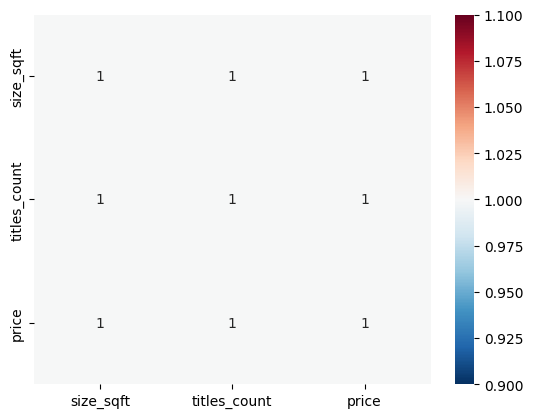

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(corr_matrix, annot = True, cmap = 'RdBu_r')
plt.show()

**removing highly correlated features (>0.9)**

In [17]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column]>0.9)]
print("Highly correlated features to drop: ", to_drop)

Highly correlated features to drop:  ['titles_count', 'price']


In [22]:
df.columns

Index(['size_sqft', 'titles_count', 'price'], dtype='object')

🏠 Scenario: Real Estate Price Prediction
You are developing a regression model to predict house prices.
Dataset contains:
House Size (sqft)
Number of Tiles
Total Construction Cost
Number of Bedrooms
Market Price
After calculating correlation matrix, you find:
House Size and Number of Tiles have 0.98 correlation
Construction Cost is highly correlated (0.95) with House Size
❓ Question:
Why is high correlation between features a problem?
Which feature(s) would you remove and why?
What issue can occur if highly correlated features are kept?
Which filter method is appropriate here?

✅ 1️⃣ Why is high correlation between features a problem?

When two features are highly correlated (like 0.98), it means:

👉 They contain almost the same information
👉 The model gets confused about which one is actually important

This problem is called Multicollinearity.

🔴 Why it is bad?

Coefficients become unstable

Small change in data → large change in weights

Hard to interpret model

In Linear Regression, importance becomes misleading

Example:
If House Size increases → Number of Tiles also increases.
Model cannot clearly decide which one affects price more.

✅ 2️⃣ Which feature(s) would you remove and why?

Given:

House Size ↔ Number of Tiles → 0.98

Construction Cost ↔ House Size → 0.95

🔍 Logical Removal:

Remove:
❌ Number of Tiles (because it directly depends on House Size)

Possibly remove:
❌ Construction Cost (if it is calculated based on size)

Keep:
✔ House Size (most fundamental feature)
✔ Number of Bedrooms

👉 Keep the most meaningful, direct feature.

✅ 3️⃣ What issue occurs if highly correlated features are kept?

If we keep them:

⚠️ Problem 1: Multicollinearity

Regression coefficients become unreliable.

⚠️ Problem 2: Overfitting

Model may memorize redundant patterns.

⚠️ Problem 3: Interpretation becomes difficult

You cannot confidently say which feature impacts price.

⚠️ Problem 4: Increased model variance

Predictions may fluctuate.

✅ 4️⃣ Which filter method is appropriate here?

👉 Correlation Matrix Method (Correlation-based Feature Selection)

Steps:

Calculate correlation matrix

If correlation > 0.8 or 0.9

Remove one of the correlated features

In [29]:
import pandas as pd
import numpy as np

real_estate_df = pd.DataFrame({
    'house_size': [1000, 1500, 2000, 2500, 3000],
    'no_of_tiles': [100, 150, 200, 250, 300],
    'total_construction_cost': [200000, 300000, 400000, 500000, 600000],
    'no_of_bedrooms': [1, 1, 2, 2, 3],
    'market_price': [240000, 310000, 430000, 510000, 640000],
})
real_estate_df

,house_size,no_of_tiles,total_construction_cost,no_of_bedrooms,market_price
0,1000,100,200000,1,240000
1,1500,150,300000,1,310000
2,2000,200,400000,2,430000
3,2500,250,500000,2,510000
4,3000,300,600000,3,640000


In [30]:
#correlation matrix
correlation_matrix = real_estate_df.corr()
correlation_matrix

,house_size,no_of_tiles,total_construction_cost,no_of_bedrooms,market_price
house_size,1.000000,1.000000,1.000000,0.944911,0.995431
no_of_tiles,1.000000,1.000000,1.000000,0.944911,0.995431
total_construction_cost,1.000000,1.000000,1.000000,0.944911,0.995431
no_of_bedrooms,0.944911,0.944911,0.944911,1.000000,0.970693
market_price,0.995431,0.995431,0.995431,0.970693,1.000000


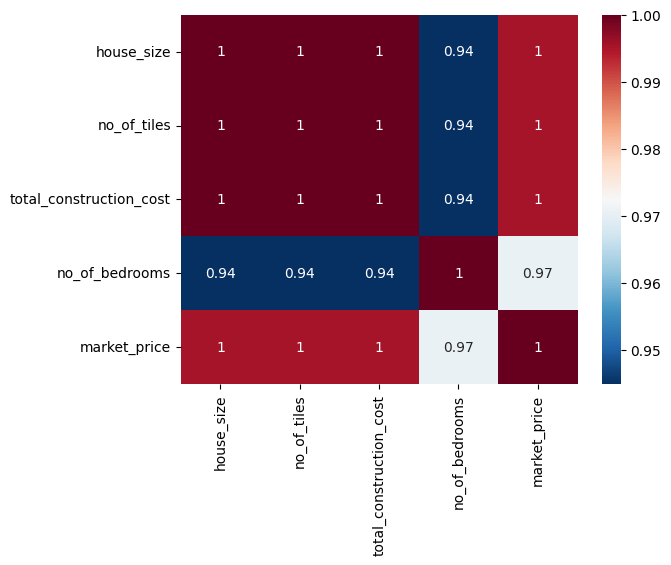

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(correlation_matrix, annot = True, cmap = 'RdBu_r')
plt.show()

In [32]:
upper1 = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k = 1).astype(bool)
)

to_drop = [column for column in upper1.columns if any(upper1[column]>0.9)]
print("Highly correlated features to drop: ", to_drop)

Highly correlated features to drop:  ['no_of_tiles', 'total_construction_cost', 'no_of_bedrooms', 'market_price']


# **Chi-Square Test**

In [34]:
x = pd.DataFrame({
    'gender': [0, 1, 0, 1, 1], #0:female and 1:male
    'married': [1, 1, 0, 0, 1],
    'income': [20000, 40000, 50000, 30000,60000]
})

y = [0, 1, 1, 0, 1]

x

,gender,married,income
0,0,1,20000
1,1,1,40000
2,0,0,50000
3,1,0,30000
4,1,1,60000


In [38]:
#Chi-Square requires non-negative values

from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import MinMaxScaler

scalar = MinMaxScaler()
x_scaled = scalar.fit_transform(x)

selector = SelectKBest(score_func = chi2, k=2)
x_new = selector.fit_transform(x_scaled, y)

selected_features = x.columns[selector.get_support()]
print("selected features: ",selected_features)

selected features:  Index(['married', 'income'], dtype='object')


Scenario: Loan Approval Classification
You are building a classification model to predict whether a loan will be approved.
Dataset features:
Gender (Male/Female)
Marital Status (Yes/No)
Education Level (Graduate/Non-Graduate)
Applicant Income
Property Area (Urban/Rural)
Favorite Color
Loan Status (Approved/Rejected)
You want to identify which categorical features significantly influence loan approval.
❓ Question:
Which filter method is most appropriate here?
Which type of features can be tested using this method?
If “Favorite Color” has a very low chi-square score, what does it indicate?
Why is chi-square suitable only for classification problems?


✅ 1️⃣ Which filter method is most appropriate here?

👉 Chi-Square Test (χ² Feature Selection)

Because:

Target variable (Loan Status) is categorical (Approved / Rejected)

Most input features are categorical

So Chi-Square is the best filter method here.

✅ 2️⃣ Which type of features can be tested using this method?

Chi-Square works for:

✔ Categorical input features
✔ Non-negative numerical features (after encoding)
✔ Classification target variable

Examples from dataset:

Gender

Marital Status

Education Level

Property Area

Favorite Color

It is mainly used to test relationship between:

Categorical Feature ↔ Categorical Target

✅ 3️⃣ If “Favorite Color” has a very low chi-square score, what does it indicate?

It means:

👉 Favorite Color has very weak or no relationship with Loan Approval.

In simple words:

The loan approval decision does NOT depend on favorite color.

So we can:
❌ Remove "Favorite Color" from dataset.

✅ 4️⃣ Why is Chi-Square suitable only for classification problems?

Because:

Chi-Square measures:

Association between two categorical variables

It compares:

Observed frequency

Expected frequency

But in regression:

Target variable is continuous (like price, income)

There are no frequency counts

So Chi-Square cannot be applied

Hence:
✔ Suitable for Classification
❌ Not suitable for Regression

In [42]:
import pandas as pd

loan_df_x = pd.DataFrame({
    "Gender": ["Male", "Female", "Male", "Male", "Female"],
    "Marital_Status": ["Yes", "No", "Yes", "No", "Yes"],
    "Education_Level": ["Graduate", "Non-Graduate", "Graduate", "Graduate", "Non-Graduate"],
    "Applicant_Income": [50000, 30000, 45000, 60000, 25000],
    "Property_Area": ["Urban", "Rural", "Urban", "Rural", "Urban"],
    "Favorite_Color": ["Blue", "Red", "Green", "Blue", "Red"],

})
loan_df_y = ["Approved", "Rejected", "Approved", "Approved", "Rejected"]




In [47]:
import pandas as pd
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import MinMaxScaler

# Step 1: Separate X and y
loan_df_x = df.drop("Loan_Status", axis=1)
loan_df_y = df["Loan_Status"]

# Step 2: Encode categorical variables
loan_df_x_encoded = pd.get_dummies(loan_df_x, drop_first=True)

# Convert target also to numeric
loan_df_y_encoded = loan_df_y.map({"Rejected": 0, "Approved": 1})

# Step 3: Scale features (Chi-square requires non-negative values)
sc = MinMaxScaler()
loan_x_scaled = sc.fit_transform(loan_df_x_encoded)

# Step 4: Apply Chi-Square
loan_selector = SelectKBest(score_func=chi2, k=3)
loan_x_new = loan_selector.fit_transform(loan_x_scaled, loan_df_y_encoded)

# Step 5: Get selected feature names
loan_selected_features = loan_df_x_encoded.columns[loan_selector.get_support()]

print("Selected features:", loan_selected_features)


Selected features: Index(['Gender_Male', 'Education_Level_Non-Graduate', 'Favorite_Color_Red'], dtype='object')
